In [ ]:
Lecture 4
Median and Selection

Part 1: Substitution Method

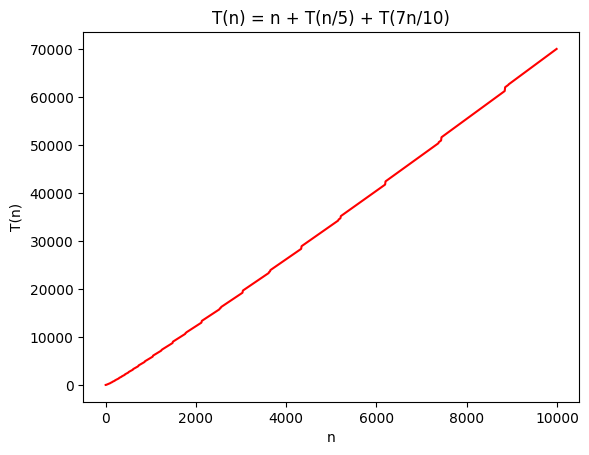

In [ ]:
%matplotlib inline
import matplotlib
import numpy as np
import matplotlib.pyplot as plt

def nastyRecurrence(n):
    if n <= 10:
        return 1
    return n + nastyRecurrence(n/5) + nastyRecurrence(7*n/10)

nVals = list( range(1,10000,10))
rVals = [ nastyRecurrence(n) for n in nVals]
plt.plot( nVals, rVals, color="red")
plt.xlabel("n")
plt.ylabel("T(n)")
plt.title("T(n) = n + T(n/5) + T(7n/10)")
plt.show()



```
# This is formatted as code
```

Part 2: SELECT
Here are a bunch of different ways we might pick a pivot.
We'll see our final way (chooseFancyFivePivot) later on in this notebook.

In [9]:

import time
from random import choice

# trySelectABunch: runs an implementation of SELECT a bunch, and times how long it takes.
#
# Input: myFn: a function which takes as input a list of integers
# Output: lists nValues and tValues so that running myFn on a list of length nValues[i] took (on average over numTrials tests) time tValues[i] milliseconds.
#
# Other optional args:
#    - Ns: list of inputs n to test
#    - numTrials: for each n tests, do numTrials tests and average them
#    - listMax: the input lists of length n will have values drawn uniformly at random from range(listMax)
#    - random: if True uses a random list.  If not just uses the numbers 1 through n.  (Useful for seeing the effect of bad pivots)
def trySelectABunch(myFn, Ns = range(10,100,10), numTrials=20, listMax = 10, random=True):
    nValues = []
    tValues = []
    for n in Ns:
        # run myFn several times and average to get a decent idea.
        runtime = 0
        for t in range(numTrials):
            if random:
                lst = [ choice(range(listMax)) for i in range(n) ] # generate a random list of length n
            else:
                lst = [ i for i in range(n) ] # just use the numbers 1-n.
            k = choice(range(1,n+1))
            start = time.time()
            myFn( lst , k)
            end = time.time()
            runtime += (end - start) * 1000 # measure in milliseconds
        runtime = runtime/numTrials
        nValues.append(n)
        tValues.append(runtime)
    return nValues, tValues

# We'll also want to use our earlier implementation of mergeSort
def merge(L, R):
    i = 0 # current index in the L array
    j = 0 # current index in the R array
    ret = []
    while i < len(L) and j < len(R):
        if L[i] < R[j]:
            ret.append(L[i])
            i += 1
        else:   # ties go to R.  Doesn't really matter.
            ret.append(R[j])
            j += 1
    while i < len(L):
        ret.append(L[i])
        i += 1
    while j < len(R):
        ret.append(R[j])
        j+= 1
    return ret

def mergeSort(A):
    n = len(A)
    if n <= 1:
        return A
    L = mergeSort(A[:round(n/2)])
    R = mergeSort(A[round(n/2):n])
    return merge(L,R)



# Choose a random pivot; this takes time O(1)
def chooseRandomPivot(A):
    return choice( range(len(A)))

# Choose the pivot to be n/2; also takes time O(1)
def chooseArbitraryPivot(A):
    return round(len(A)/2)
# Choose the pivot to be t (unless the array is shorter than t); takes time O(1)
def chooseMyFavoritePivot(A,t=3):
    if len(A) < t+1:
        return 0
    return t

# this finds the "best" pivot (that is, that splits the array in half); but in runs in time O(n log(n))
def chooseIdealPivot(A):
    B = A[:]
    B.sort()
    pivotVal = B[(len(B)/2).__trunc__()]
    return A.index(pivotVal)

# this finds the *worst* pivot; runs in time O(n)
def chooseWorstPivot(A):
    m = min(A)
    return A.index(m)

# Returns L, A[p], R, where L has all the elements less or equal to A[p], R has all the elements greater than A[p]
def myPartition(A, p):
    L = []
    R = []
    for i in range(len(A)):
        if i == p:
            continue
        if A[i] <= A[p]: # This is NOT a good idea if the array doesn't have distinct elts.  (Why?)
            L.append(A[i])
        else:
            R.append(A[i])
    return L, A[p], R

# Returns the k'th smallest element of A
def mySelect( A, k ):
    if len(A) <= 50:
        A = mergeSort(A)
        return A[k-1]
    p = chooseFancyFivePivot(A) # We can plug in whatever choosePivot algorithm we want here!
    L, mid, R = myPartition(A,p)
    if len(L) == k-1:
        return mid
    elif len(L) > k-1: # then the k'th smallest thing is the k'th smallest thing in the left half
        return mySelect(L, k)
    elif len(L) < k-1: # then the k'th smallest thing is the (k - len(L) - 1)'st smallest thing in the right half
        return mySelect(R, k - len(L) - 1)

# Let's make sure it works!  Make a list with all the numbers from 1 to 49 in some order
from random import shuffle
A = list(range(1,50))
shuffle(A)
print(A)

# k'th smallest should be k
print("The 6'th smallest is", mySelect(A, 6))
print("The 12'th smallest is", mySelect(A, 12))
print("The 15'th smallest is", mySelect(A, 15))

[34, 10, 43, 15, 42, 33, 48, 29, 44, 39, 13, 24, 11, 21, 37, 27, 12, 16, 17, 3, 46, 49, 23, 9, 2, 6, 26, 4, 19, 38, 35, 22, 31, 25, 45, 1, 28, 5, 40, 32, 14, 41, 47, 18, 8, 30, 36, 20, 7]
The 6'th smallest is 6
The 12'th smallest is 12
The 15'th smallest is 15


How long does it take?
Let's try a few different pivot strategies and also the sort-it-and-find-the-right-value strategy.

Text(0.5, 1.0, 'Selection')

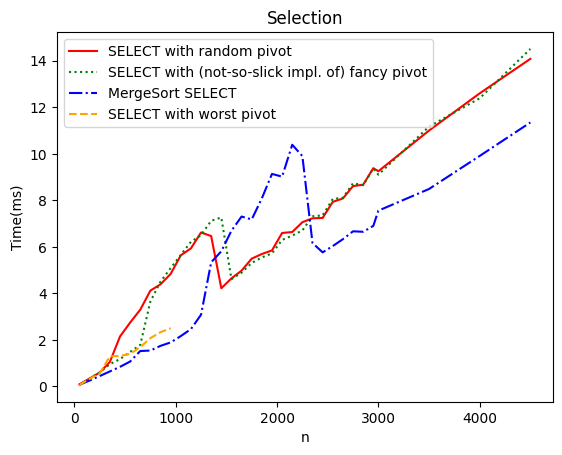

In [12]:
# first define a naive (nlog(n)-time) median algorithm to use for the groups of size 5.
def naiveMedian(A):
    A = mergeSort(A) # nlogn time sorting alg
    return A[(len(A)/2).__trunc__()]

# this is the final pivot selection algorithm described on the slides
# (not implemented very slickly)
# it finds a "pretty good" pivot (splits the array close to in half).
# It runs in time O(n), in addition to a call to mySelect.
def chooseFancyFivePivot(A):
    # first, split A into n/5 groups, and find the median of each group.
    current = 0
    submedians = []
    while current < len(A):
        if current + 5 < len(A):
            currentGrp = A[current:current+5]
        else:
            currentGrp = A[current:]
        submedians.append( naiveMedian(currentGrp) )
        current += 5
    # now that we have our list of sub-medians, we'll find what the median is of those,
    # using a recursive call to mySelect.
    pivotVal = mySelect( submedians, (len(submedians)/2).__trunc__() )
    # now we should actually return the index of pivotVal.
    # if we were being smart we would have implemented mySelect to just do this,
    # but since we're interested in clarity and big-oh runtime, we'll just find the index in O(n) time.
    for i in range(len(A)):
        if A[i] == pivotVal:
            return i
    print("If we ever get to this stage, that's a problem!")


nVals = list(range(50, 3050, 100)) + list(range(3000, 5000, 500))
# run this cell when we have chooseRandomPivot in mySelect
nValuesRandom, tValuesRandom = trySelectABunch(mySelect, Ns = nVals, numTrials=50, listMax = 100000)

# Try this one when we have chooseMyFavoritePivot(A,0) in mySelect,
# and then we'll choose the random=False flag in trySelectABunch, which chooses an array that's worst-case for the choice of p=0.
# Only go up to 1000 since it takes too long...
nValsSmall = range(50, 1000, 100)
nValuesWorst, tValuesWorst = trySelectABunch(mySelect, Ns=nValsSmall, numTrials=25, listMax = 100000, random=False)

# Try this one when we have chooseFancyFivePivot in mySelect; chooseFancyFivePivot is defined above, so come back to this.
nValuesFancy, tValuesFancy = trySelectABunch(mySelect, Ns=nVals, numTrials=50, listMax = 100000)

def mergeSortSelect(A,k):
    A = mergeSort(A)
    return A[k-1]

# Now try mergeSortSelect
nValuesMerge, tValuesMerge = trySelectABunch(mergeSortSelect, Ns=nVals, numTrials=50, listMax = 100000)

plt.plot(nValuesRandom, tValuesRandom, color="red", label="SELECT with random pivot")
# Comment out the next line until you've generated nValuesFancy, tValuesFancy
plt.plot(nValuesFancy, tValuesFancy, ":", color="green", label="SELECT with (not-so-slick impl. of) fancy pivot")
plt.plot(nValuesMerge, tValuesMerge, "-.", color="blue", label="MergeSort SELECT")
plt.plot(nValuesWorst, tValuesWorst, "--", color="orange", label="SELECT with worst pivot")
plt.xlabel("n")
plt.ylabel("Time(ms)")
plt.legend()
plt.title("Selection")